In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# Настройка красивых графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

class Dot(object):
    def __init__(self, coords, t):
        self.coords = coords
        self.t = t

def YaMRK_4(dot: Dot, f, dt):
    k1 = dt * f(dot.coords, dot.t)
    k2 = dt * f(dot.coords + 0.5 * k1, dot.t + 0.5 * dt)
    k3 = dt * f(dot.coords + 0.5 * k2, dot.t + 0.5 * dt)
    k4 = dt * f(dot.coords + k3, dot.t + dt)
    return Dot(dot.coords + 1/6 * (k1 + 2*k2 + 2*k3 + k4), dot.t + dt)

def YaMRK(dot: Dot, f, dt, t_max):
    ret = list()
    while dot.t <= t_max + 1e-9: 
        ret.append(dot)
        dot = YaMRK_4(dot, f, dt)
    return ret

In [2]:
def shooting_method(system_func, y0_func, param_guess, x_span, 
                    target_val=0.0, save_history=False, eval_points=100):
    param = param_guess
    history = []
    
    tol = 1e-6
    max_iter = 20
    
    dt = (x_span[1] - x_span[0]) / (eval_points - 1)
    
    for i in range(max_iter):
        current_system = lambda Y, x: np.array(system_func(x, Y, param))
        
        Y0 = np.array(y0_func(param))
        start_dot = Dot(Y0, x_span[0])
        
        dots = YaMRK(start_dot, current_system, dt=dt, t_max=x_span[1])
        
        x_arr = np.array([d.t for d in dots])
        Y_arr = np.array([d.coords for d in dots]).T # Транспонируем, чтобы было (num_vars, num_points)
        
        y_end = Y_arr[0, -1]     # индекс 0: целевая функция y_1
        deriv_end = Y_arr[2, -1] # индекс 2: производная невязки по параметру u
        
        # Вычисляем невязку по отношению к целевому значению
        residual = y_end - target_val
        
        if save_history:
            history.append({'param': param, 'x': x_arr, 'y': Y_arr[0]})
            
        if abs(residual) < tol:
            if save_history:
                return x_arr, Y_arr[0], param, history
            return x_arr, Y_arr[0], param
        
        # Шаг метода Ньютона
        param = param - residual / deriv_end
        
    raise RuntimeError(f"Метод не сошелся за {max_iter} итераций для начального приближения {param_guess}")


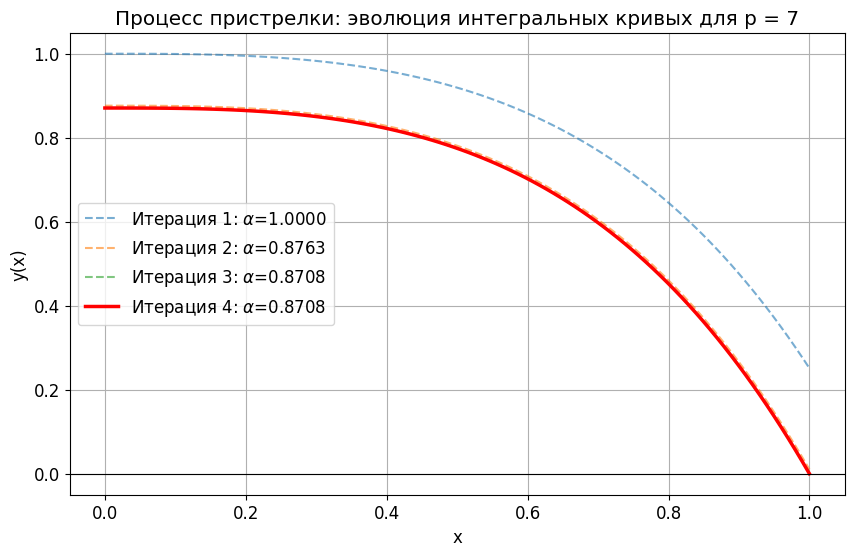

In [3]:
# Правая часть расширенной системы для задачи 1.1
def sys_1a(x, Y, alpha, p):
    y1, y2, u, v = Y
    return [y2, 
            -p * x * np.cos(y1), 
            v, 
            p * x * np.sin(y1) * u]

# Начальные условия: y1(0)=alpha, y2(0)=0, u(0)=1, v(0)=0
def y0_1a(alpha):
    return [alpha, 0.0, 1.0, 0.0]

# Демонстрация процесса пристрелки для p = 7
x_sol, y_sol, alpha_final, history = shooting_method(
    system_func=lambda x, Y, a: sys_1a(x, Y, a, p=7), 
    y0_func=y0_1a, param_guess=1.0, x_span=[0, 1], save_history=True
)

plt.figure(figsize=(10, 6))
for i, step in enumerate(history):
    alpha_val = step['param']
    if i == len(history) - 1:
        plt.plot(step['x'], step['y'], 'r-', linewidth=2.5, label=f'Итерация {i+1}: $\\alpha$={alpha_val:.4f}')
    else:
        plt.plot(step['x'], step['y'], '--', alpha=0.6, label=f'Итерация {i+1}: $\\alpha$={alpha_val:.4f}')

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Процесс пристрелки: эволюция интегральных кривых для p = 7')
plt.xlabel('x'); plt.ylabel('y(x)')
plt.legend(); plt.show()




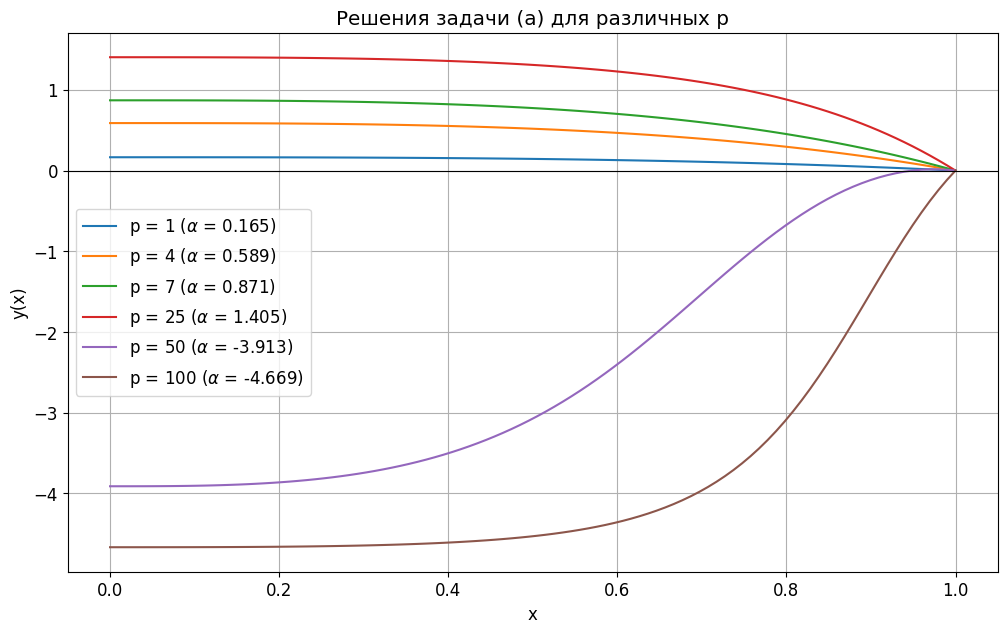

In [4]:
# Решение задачи для различных параметров p
p_values = [1, 4, 7, 25, 50, 100]
guesses = {1: 1.0, 4: 1.0, 7: 1.0, 25: 1.0, 50: 3.0, 100: -10.0}
plt.figure(figsize=(12, 7))

for p in p_values:
    try:
        x_sol, y_sol, alpha_final = shooting_method(
            system_func=lambda x, Y, a: sys_1a(x, Y, a, p=p), 
            y0_func=y0_1a, param_guess=guesses[p], x_span=[0, 1]
        )
        plt.plot(x_sol, y_sol, label=f'p = {p} ($\\alpha$ = {alpha_final:.3f})')
    except RuntimeError as e:
        print(e)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Решения задачи (а) для различных p')
plt.xlabel('x'); plt.ylabel('y(x)')
plt.legend(); plt.show()

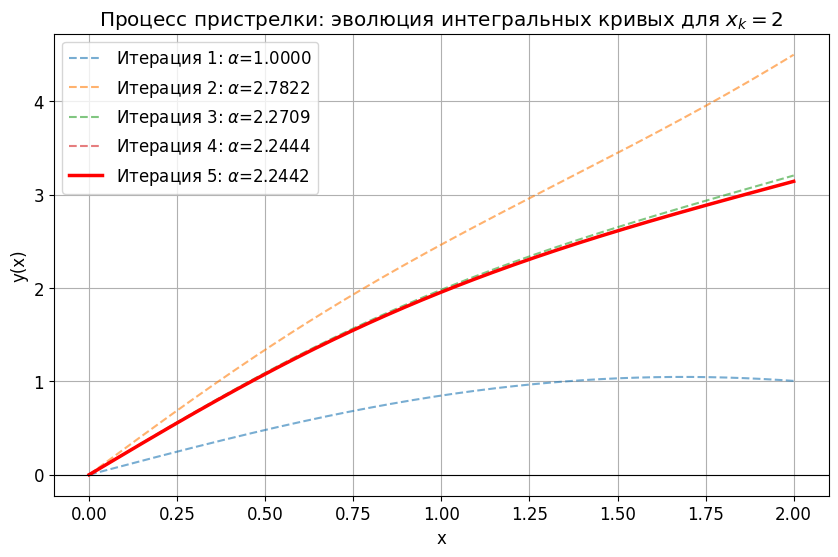

In [5]:
# Правая часть расширенной системы для задачи 1.2
def sys_1v(x, Y, alpha):
    y1, y2, u, v = Y
    return [y2, 
            -np.sin(y1), 
            v, 
            -np.cos(y1) * u]

# Начальные условия: y1(0)=0, y2(0)=alpha, u(0)=0, v(0)=1
def y0_1v(alpha):
    return [0.0, alpha, 0.0, 1.0]

x_sol, y_sol, alpha_final, history = shooting_method(
    system_func=sys_1v, 
    y0_func=y0_1v, param_guess=1, x_span=[0, 2], target_val=np.pi, eval_points=200, save_history=True
)

plt.figure(figsize=(10, 6))
for i, step in enumerate(history):
    alpha_val = step['param']
    if i == len(history) - 1:
        plt.plot(step['x'], step['y'], 'r-', linewidth=2.5, label=f'Итерация {i+1}: $\\alpha$={alpha_val:.4f}')
    else:
        plt.plot(step['x'], step['y'], '--', alpha=0.6, label=f'Итерация {i+1}: $\\alpha$={alpha_val:.4f}')

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Процесс пристрелки: эволюция интегральных кривых для $x_k = 2$')
plt.xlabel('x'); plt.ylabel('y(x)')
plt.legend(); plt.show()


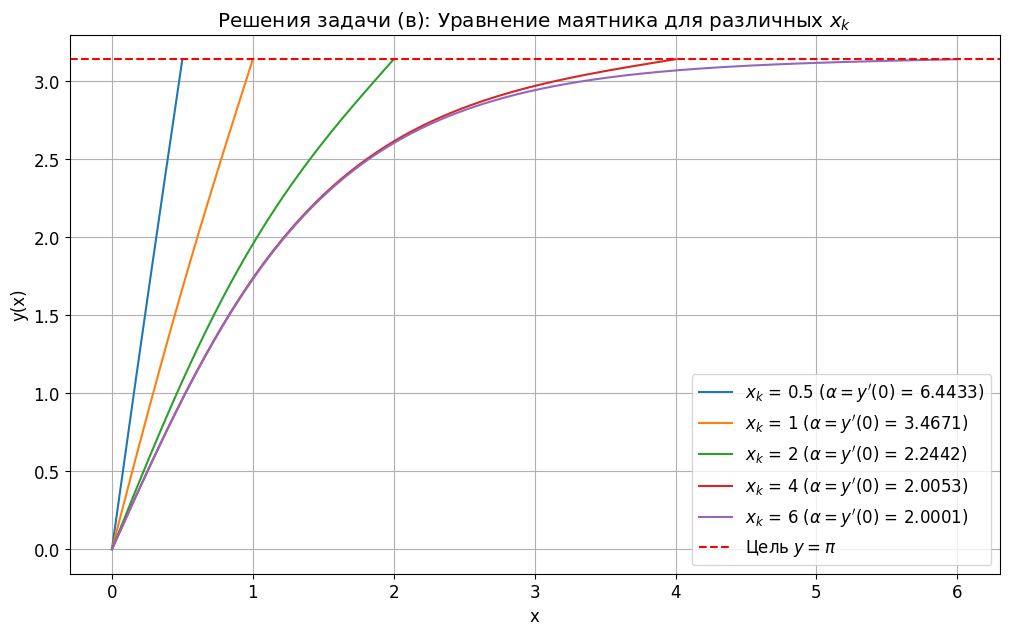

In [6]:

xk_values = [0.5, 1, 2, 4, 6]
plt.figure(figsize=(12, 7))

guesses_v = {0.5: 6.5, 1: 3.5, 2: 2.2, 4: 2.01, 6: 2.001}

for xk in xk_values:
    try:
        x_sol, y_sol, alpha_final = shooting_method(
            system_func=sys_1v, y0_func=y0_1v, param_guess=guesses_v[xk], 
            x_span=[0, xk], target_val=np.pi, eval_points=200
        )
        plt.plot(x_sol, y_sol, label=f'$x_k$ = {xk} ($\\alpha = y\'(0)$ = {alpha_final:.4f})')
    except RuntimeError as e:
        print(e)

plt.axhline(np.pi, color='r', linestyle='--', linewidth=1.5, label='Цель $y=\\pi$')
plt.title('Решения задачи (в): Уравнение маятника для различных $x_k$')
plt.xlabel('x'); plt.ylabel('y(x)')
plt.legend(); plt.show()

История итераций метода стрельбы для $\lambda$:
Итерация 0: lambda = -0.900000
Итерация 1: lambda = -1.275391
Итерация 2: lambda = -1.174454
Итерация 3: lambda = -1.092791
Итерация 4: lambda = -1.035662
Итерация 5: lambda = -1.007034
Итерация 6: lambda = -1.000328
Итерация 7: lambda = -0.999999
Итерация 8: lambda = -0.999999
Итерация 9: lambda = -0.999999

Итоговое найденное собственное значение: lambda = -0.999999


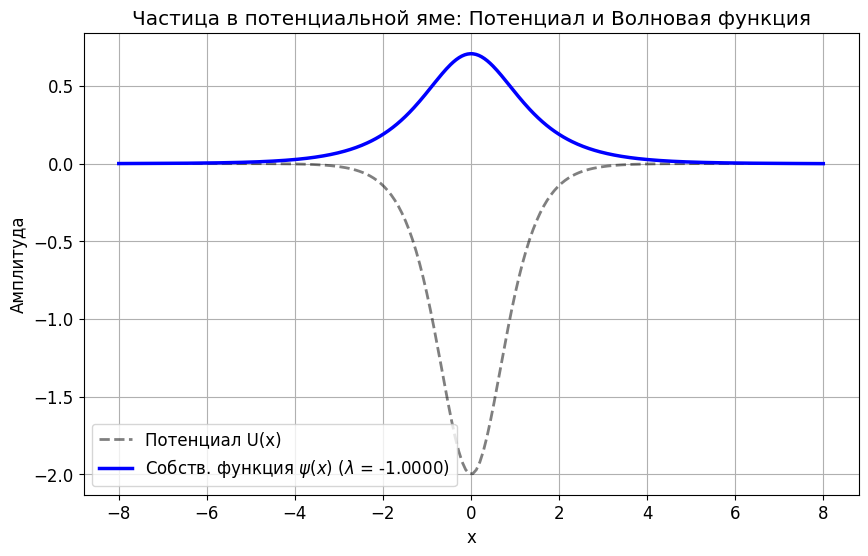

In [8]:
# Потенциал
def U(x):
    return -2.0 / (np.cosh(x)**2)

L = 8.0

# Правая часть расширенной системы для поиска собственных значений
def sys_2(x, Y, lam):
    y1, y2, u, v = Y
    return [y2, 
            (U(x) - lam) * y1, 
            v, 
            (U(x) - lam) * u - y1]

# Начальные условия: y1(-L)=0, y2(-L)=1, u(-L)=0, v(-L)=0
# Производные начальных условий по lambda равны нулю, т.к. они фиксированы и от lambda не зависят.
def y0_2(lam):
    return [0.0, 1.0, 0.0, 0.0]

initial_guess = -0.9
x_sol, y_sol, lam_final, history = shooting_method(
    system_func=sys_2, y0_func=y0_2, param_guess=initial_guess, 
    x_span=[-L, L], save_history=True, eval_points=200
)

print("История итераций метода стрельбы для $\\lambda$:")
for i, step in enumerate(history):
    print(f"Итерация {i}: lambda = {step['param']:.6f}")
print(f"\nИтоговое найденное собственное значение: lambda = {lam_final:.6f}")

# Построение собственной функции распределения (с нормировкой)
plt.figure(figsize=(10, 6))
plt.plot(x_sol, U(x_sol), 'k--', linewidth=2, alpha=0.5, label='Потенциал U(x)')

# Восстанавливаем решение напрямую через ЯМРК для найденного lam_final
def final_system(Y, x):
    y1, y2 = Y
    return np.array([y2, (U(x) - lam_final) * y1])

dt = (L - (-L)) / 499
start_dot = Dot(np.array([0.0, 1.0]), -L)
dots = YaMRK(start_dot, final_system, dt=dt, t_max=L)

x_final = np.array([d.t for d in dots])
y_final = np.array([d.coords[0] for d in dots])

# Нормировка волновой функции
norm_factor = np.sqrt(simpson(y=y_final**2, x=x_final))
y_eigen_normalized = y_final / norm_factor

plt.plot(x_final, y_eigen_normalized, linewidth=2.5, color='blue',
         label=f'Собств. функция $\\psi(x)$ ($\\lambda$ = {lam_final:.4f})')

plt.title('Частица в потенциальной яме: Потенциал и Волновая функция')
plt.xlabel('x')
plt.ylabel('Амплитуда')
plt.legend()
plt.show()